## Analysis process - Dianela

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

In [2]:
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.


# FINAL VERSION:

In [ ]:
# ============================================================
# PP422 — LSE Growth Co-Lab
# Frontier Sector Presence and Growth Analysis
# Final analysis code — March 2026
# ============================================================
# STRUCTURE:
#   0. Imports and configuration
#   1. Load data
#   2. Build outcome variables (LQ, delta_lq)
#   3. Build analysis sample (England, 5 sectors)
#   4. Diagnostics and descriptive statistics
#   5. LASSO variable selection
#   6. Results visualisation
#   7. Post-selection OLS with clustered standard errors
#   8. Robustness checks
# ============================================================

In [2]:
# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
PURPLE = "#534AB7"
AMBER  = "#BA7517"
GRAY   = "#5F5E5A"

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


In [3]:
# ============================================================
# 0. CONFIGURATION
# ============================================================

# Final indicator list — confirmed per codebook and diagnostics
LAD_INDICATORS = [
    # Human capital
    "level_3+_qualifications",
    "gcse_by_age_19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_and_skills_participation",
    # Entrepreneurial discovery
    "new_enterprises",
    "deaths_of_enterprises",
    "active_enterprises",
    "high_growth_enterprises",
    # Connectivity
    "broadband_availability",
    "4g_area_coverage",
    # Place
    "net_additions",
    # Derived
    "related_variety",
]

# Excluded per codebook:
#   gva_per_hour, weekly_pay, gdhi_per_head, employment_rate → reverse causality
#   unemployment_rate → r=-0.07 with outcomes, costs 21 LADs
#   transport variables (3) → missing 17 English LADs + all Scotland/Wales
#   health/wellbeing (10) → no EEG mechanism
#   early years (3) → 15-20yr lag, no current workforce link
#   ks2, ofsted, persistent_absences → county level only

SECTORS_EXCLUDED  = ["Defence", "Life Sciences"]
REFERENCE_SECTOR  = "Professional and Business Services"
BASE_YEAR         = 2016
END_YEAR          = 2022


In [4]:
# ============================================================
# 1. LOAD DATA
# ============================================================

import pandas as pd
from pathlib import Path

root = next(p for p in Path.cwd().parents if (p / "config.yml").exists())

df = pd.read_parquet(
    root / "data/processed_data/analysis_panel.parquet", engine='fastparquet'
)
print(df.shape)
print(df.dtypes)
df.head(50)
df.columns = df.columns.str.strip().str.lower()


(17150, 57)
YEAR                               int16
GEOGRAPHY_CODE                  category
GEOGRAPHY_NAME                  category
IS8_SECTOR                      category
EMPLOYEES                        float32
BUSINESSES                       float32
gva_per_hour                     float64
weekly_pay                       float64
employment_rate                  float64
unemployment_rate                float64
gdhi_per_head                    float64
new_enterprises                  float64
deaths_of_enterprises            float64
active_enterprises               float64
high_growth_enterprises          float64
public_transport_to_employer     float64
drive_to_employer                float64
cycle_to_employer                float64
broadband_availability           float64
4g_area_coverage                 float64
ks2_attainment                   float64
gcse_by_age_19                   float64
ofsted                           float64
persistent_absences              float64
pers

In [6]:
print(df.shape)
print(df.columns.tolist())
print(df['is8_sector'].unique())

(17150, 57)
['year', 'geography_code', 'geography_name', 'is8_sector', 'employees', 'businesses', 'gva_per_hour', 'weekly_pay', 'employment_rate', 'unemployment_rate', 'gdhi_per_head', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'public_transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband_availability', '4g_area_coverage', 'ks2_attainment', 'gcse_by_age_19', 'ofsted', 'persistent_absences', 'persistent_absences_fsm', 'persistent_absences_cla', 'early_years_comms', 'early_years_literacy', 'early_years_maths', 'fe_and_skills_achievements', 'apprenticeship_starts', 'apprenticeship_achievements', 'level_3+_qualifications', 'fe_and_skills_participation', 'female_hle', 'male_hle', 'smokers', 'reception_obesity', 'year_6_obesity', 'adult_obesity', 'cancer_diagnosis', 'under_75_mortality_rate', 'life_satisfaction', 'worthwhile', 'happiness', 'anxiety', 'net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'growth_emp', 'cagr_

In [7]:
for col in df.columns.tolist():
    print(col)

year
geography_code
geography_name
is8_sector
employees
businesses
gva_per_hour
weekly_pay
employment_rate
unemployment_rate
gdhi_per_head
new_enterprises
deaths_of_enterprises
active_enterprises
high_growth_enterprises
public_transport_to_employer
drive_to_employer
cycle_to_employer
broadband_availability
4g_area_coverage
ks2_attainment
gcse_by_age_19
ofsted
persistent_absences
persistent_absences_fsm
persistent_absences_cla
early_years_comms
early_years_literacy
early_years_maths
fe_and_skills_achievements
apprenticeship_starts
apprenticeship_achievements
level_3+_qualifications
fe_and_skills_participation
female_hle
male_hle
smokers
reception_obesity
year_6_obesity
adult_obesity
cancer_diagnosis
under_75_mortality_rate
life_satisfaction
worthwhile
happiness
anxiety
net_additions
lq_bus
emp_share
lq_emp
growth_emp
cagr_emp
growth_bus
cagr_bus
related_variety
size_large_share
size_micro_share


In [5]:
print(f"  Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Years: {sorted(df['year'].unique())}")
print(f"  LADs: {df['geography_code'].nunique()}")
print(f"  Sectors: {sorted(df['is8_sector'].unique())}")

  Loaded: 17,150 rows × 57 columns
  Years: [np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022)]
  LADs: 350
  Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']


In [8]:
# ============================================================
# 2. BUILD OUTCOME VARIABLES
# ============================================================

print("\nBuilding outcome variables...")

# Extract base and end years
lq_base = (df[df["year"] == BASE_YEAR]
           [["geography_code", "geography_name", "is8_sector",
             "lq_emp", "lq_bus"]]
           .rename(columns={"lq_emp": "lq_emp_2016",
                            "lq_bus": "lq_bus_2016"}))

lq_end = (df[df["year"] == END_YEAR]
          [["geography_code", "is8_sector", "lq_emp", "lq_bus"]]
          .rename(columns={"lq_emp": "lq_emp_2022",
                           "lq_bus": "lq_bus_2022"}))

# Merge and compute delta
cs = lq_base.merge(lq_end, on=["geography_code", "is8_sector"], how="inner")
cs["delta_lq_emp"] = cs["lq_emp_2022"] - cs["lq_emp_2016"]
cs["delta_lq_bus"] = cs["lq_bus_2022"] - cs["lq_bus_2016"]

print(f"  Cross-section rows (all sectors): {len(cs):,}")
print(f"  Missing either year: {len(lq_base) + len(lq_end) - 2*len(cs)}")

# ── Merge ONS indicators (time-invariant — take from END_YEAR)
indicators_cs = (df[df["year"] == END_YEAR]
                 [["geography_code"] + LAD_INDICATORS]
                 .drop_duplicates("geography_code"))

cs = cs.merge(indicators_cs, on="geography_code", how="left")


Building outcome variables...
  Cross-section rows (all sectors): 2,450
  Missing either year: 0


In [9]:
# ============================================================
# 3. BUILD ANALYSIS SAMPLE
# ============================================================

print("\nBuilding analysis sample...")

# Step 1: Exclude Defence and Life Sciences
cs_clean = cs[~cs["is8_sector"].isin(SECTORS_EXCLUDED)].copy()
print(f"  After excluding {SECTORS_EXCLUDED}: {len(cs_clean):,} rows")

# Step 2: England only — ONS indicators are England-only
cs_clean = cs_clean[cs_clean["geography_code"].astype(str).str.startswith("E")].copy()
print(f"  England only: {len(cs_clean):,} rows ({cs_clean['geography_code'].nunique()} LADs)")

# Step 3: Drop rows missing any indicator
cs_clean = cs_clean[cs_clean[LAD_INDICATORS].notna().all(axis=1)].copy()
print(f"  After dropna on indicators: {len(cs_clean):,} rows ({cs_clean['geography_code'].nunique()} LADs)")

# Step 4: Sector dummies
def add_sector_dummies(df, reference=REFERENCE_SECTOR):
    df = pd.get_dummies(df, columns=["is8_sector"], drop_first=False, dtype=float)
    sector_cols = [c for c in df.columns if c.startswith("is8_sector_")]
    # Drop reference sector and empty columns
    sector_cols = [c for c in sector_cols
                   if reference not in c and df[c].sum() > 0]
    ref_col = [c for c in df.columns
               if c.startswith("is8_sector_") and reference in c]
    df = df.drop(columns=ref_col, errors="ignore")
    return df, sector_cols

cs_final, sector_dummies = add_sector_dummies(cs_clean)
print(f"  Sector dummies: {sector_dummies}")
print(f"\n  FINAL SAMPLE: {len(cs_final):,} rows | "
      f"{cs_final['geography_code'].nunique()} LADs | "
      f"{len(sector_dummies)+1} sectors | "
      f"{len(LAD_INDICATORS)} indicators")



Building analysis sample...
  After excluding ['Defence', 'Life Sciences']: 1,750 rows
  England only: 1,480 rows (296 LADs)
  After dropna on indicators: 1,450 rows (290 LADs)
  Sector dummies: ['is8_sector_Advanced Manufacturing', 'is8_sector_Creative Industries', 'is8_sector_Digital and Technologies', 'is8_sector_Financial Services']

  FINAL SAMPLE: 1,450 rows | 290 LADs | 5 sectors | 13 indicators



SECTION 4 — DESCRIPTIVE STATISTICS


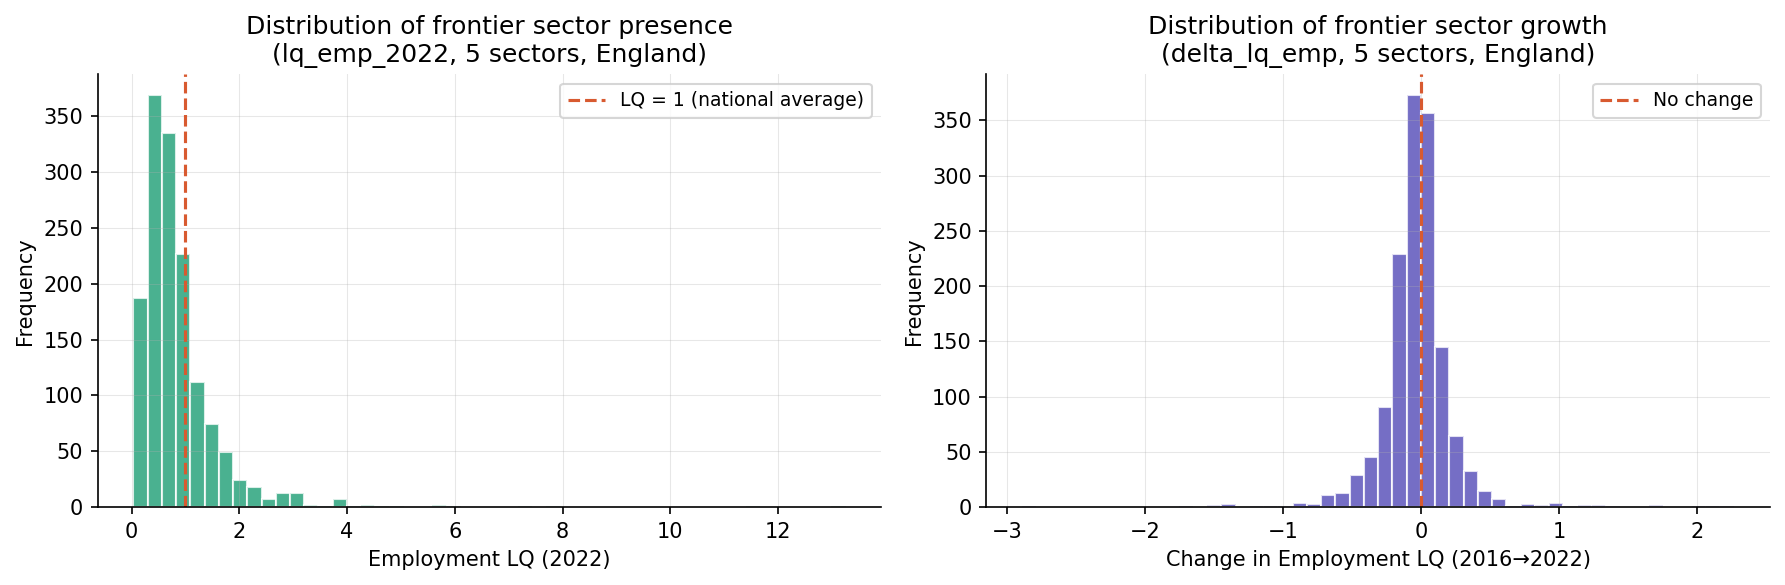

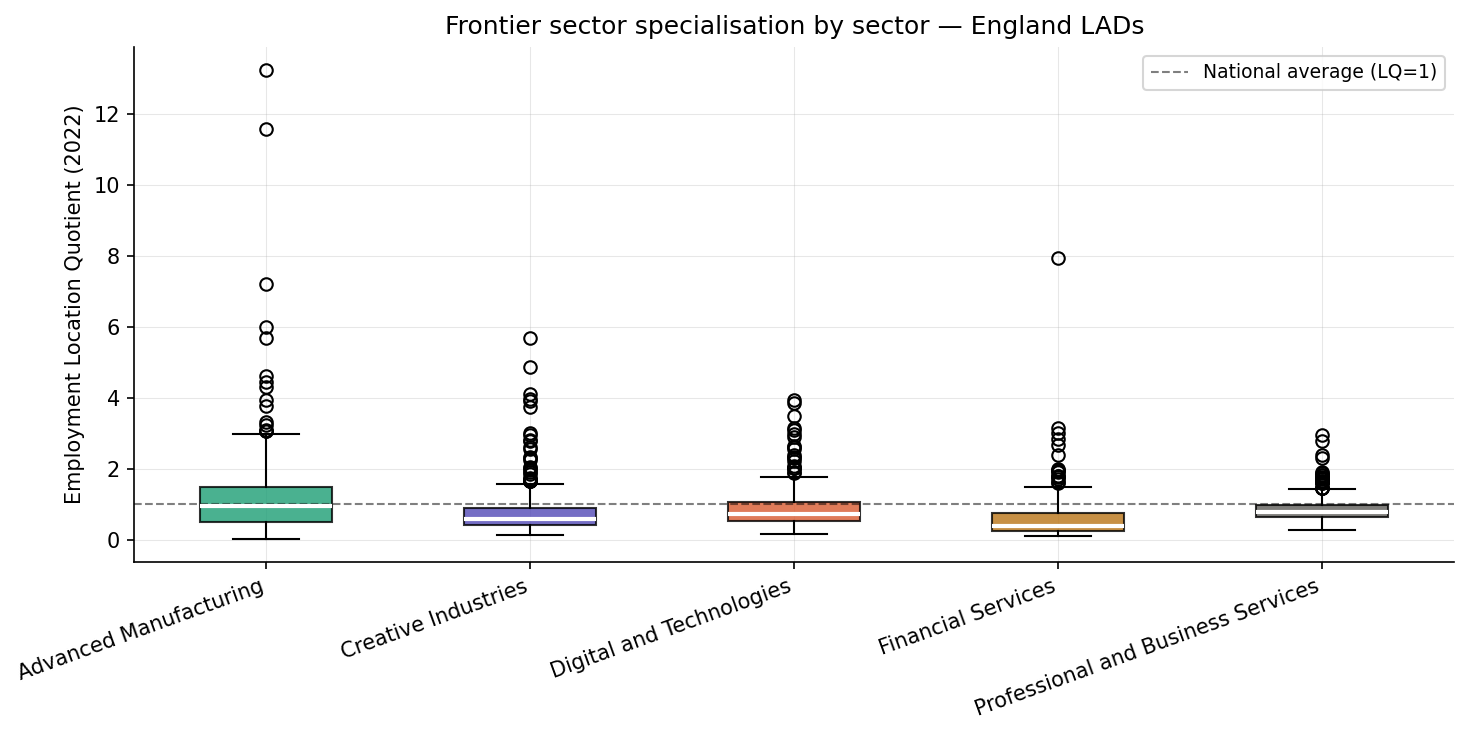

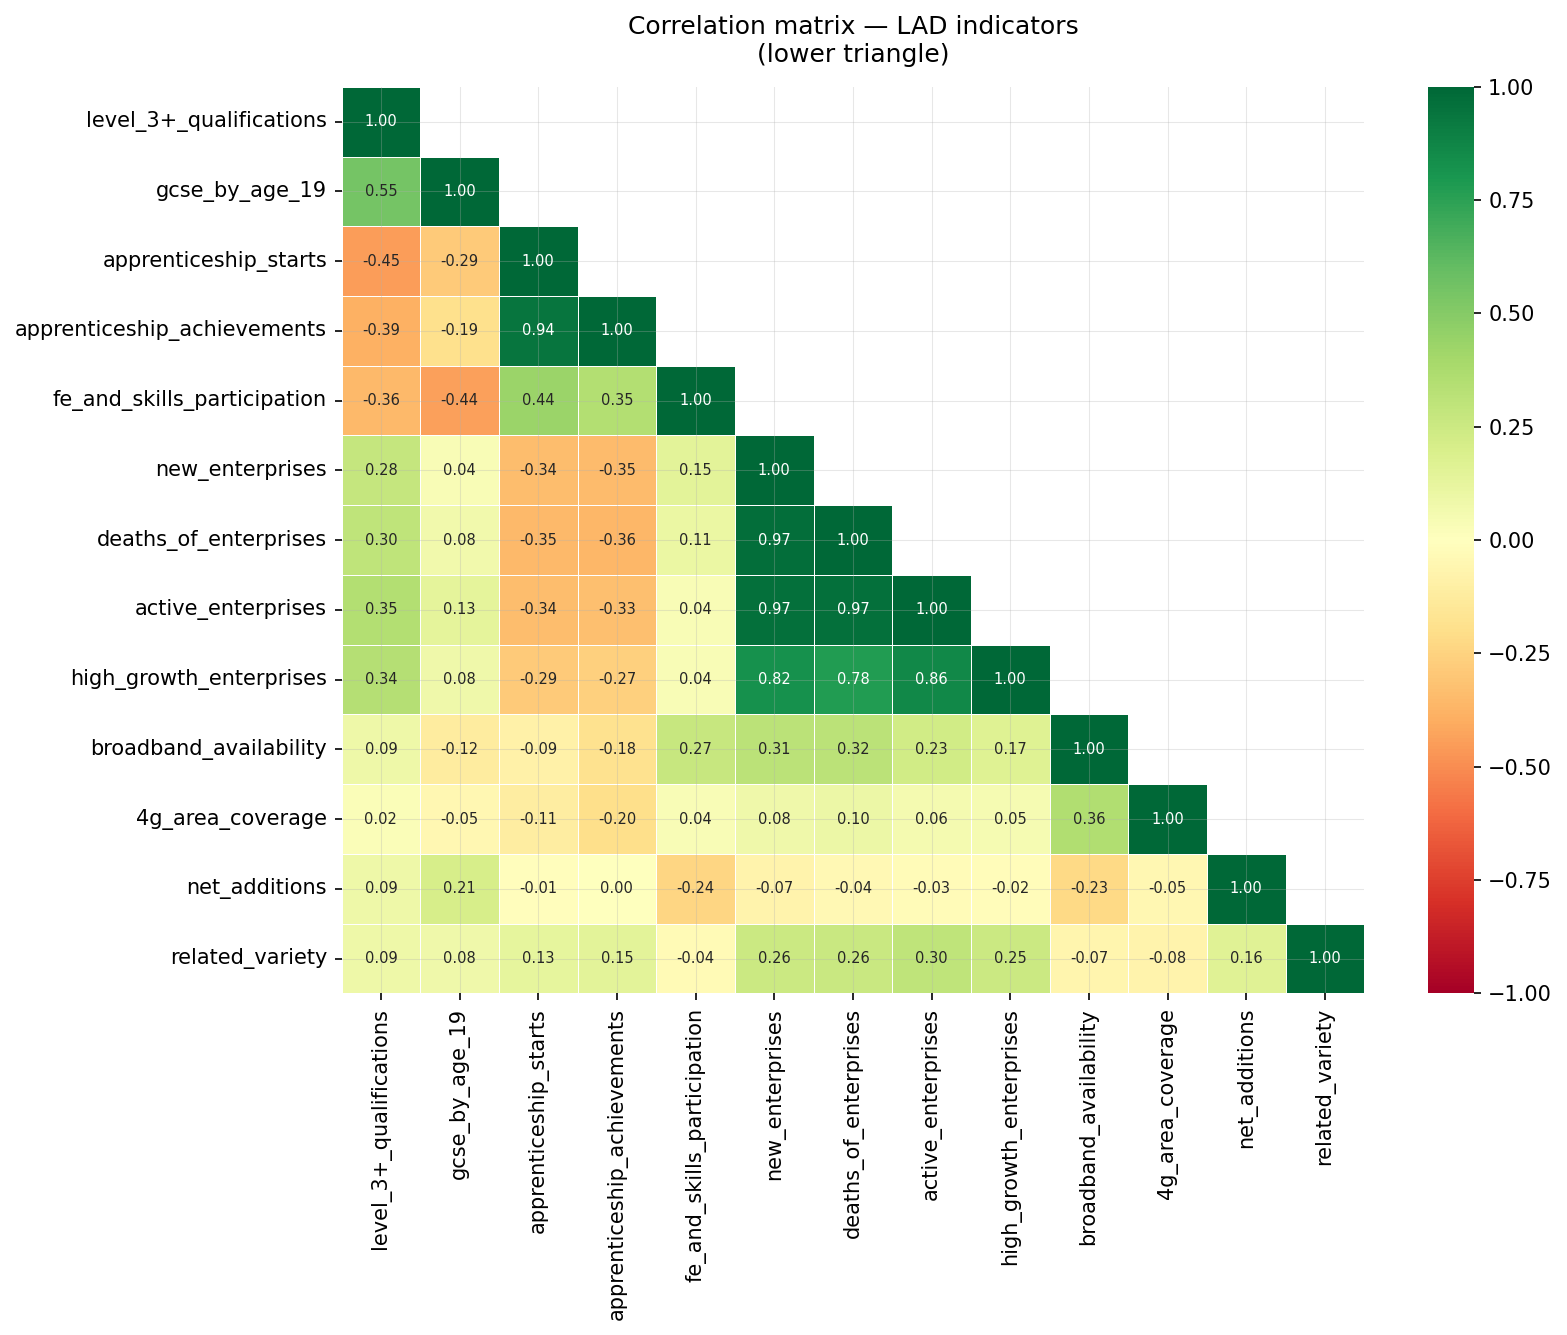


Summary statistics:
                                  N      Mean       Std       Min    Median        Max
level_3+_qualifications      1450.0    60.502     9.123    37.800    60.250     85.700
gcse_by_age_19               1450.0    75.159     5.720    53.153    75.239     88.641
apprenticeship_starts        1450.0   950.459   263.126   264.000   943.000   2736.000
apprenticeship_achievements  1450.0   457.676   140.048   111.000   452.500   1493.000
fe_and_skills_participation  1450.0  5196.934  1210.776  2611.000  4962.000  11090.000
new_enterprises              1450.0  1005.293   895.393   145.000   657.500   6670.000
deaths_of_enterprises        1450.0  1035.603   876.095   195.000   727.500   6175.000
active_enterprises           1450.0  8573.586  6741.665  1860.000  6285.000  57630.000
high_growth_enterprises      1450.0    32.897    38.165     0.000    25.000    435.000
broadband_availability       1450.0    75.504    15.510    16.500    78.250     98.600
4g_area_coverage      

In [10]:
# ============================================================
# 4. DIAGNOSTICS AND DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "="*60)
print("SECTION 4 — DESCRIPTIVE STATISTICS")
print("="*60)

# ── 4.1 Outcome variable distributions ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cs_final["lq_emp_2022"], bins=50, color=TEAL, alpha=0.8, edgecolor="white")
axes[0].axvline(1, color=CORAL, linewidth=1.5, linestyle="--", label="LQ = 1 (national average)")
axes[0].set_xlabel("Employment LQ (2022)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of frontier sector presence\n(lq_emp_2022, 5 sectors, England)")
axes[0].legend(fontsize=9)

axes[1].hist(cs_final["delta_lq_emp"], bins=50, color=PURPLE, alpha=0.8, edgecolor="white")
axes[1].axvline(0, color=CORAL, linewidth=1.5, linestyle="--", label="No change")
axes[1].set_xlabel("Change in Employment LQ (2016→2022)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of frontier sector growth\n(delta_lq_emp, 5 sectors, England)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_outcome_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4.2 LQ by sector ────────────────────────────────────────
sector_labels = {
    "is8_sector_Advanced Manufacturing": "Adv. Mfg",
    "is8_sector_Creative Industries": "Creative",
    "is8_sector_Digital and Technologies": "Digital",
    "is8_sector_Financial Services": "Financial",
}

# Rebuild sector name column for plotting
cs_plot = cs_clean.copy()

fig, ax = plt.subplots(figsize=(10, 5))
sector_order = sorted(cs_plot["is8_sector"].unique())
data_by_sector = [cs_plot[cs_plot["is8_sector"] == s]["lq_emp_2022"].values
                  for s in sector_order]
bp = ax.boxplot(data_by_sector, labels=sector_order, patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
colors = [TEAL, PURPLE, CORAL, AMBER, GRAY]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.axhline(1, color="black", linewidth=1, linestyle="--", alpha=0.5, label="National average (LQ=1)")
ax.set_ylabel("Employment Location Quotient (2022)")
ax.set_title("Frontier sector specialisation by sector — England LADs")
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_lq_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4.3 Correlation heatmap of indicators ───────────────────
corr = cs_final[LAD_INDICATORS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation matrix — LAD indicators\n(lower triangle)", pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_indicator_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4.4 Summary statistics table ────────────────────────────
summary = cs_final[LAD_INDICATORS + ["lq_emp_2022", "delta_lq_emp"]].describe().T
summary = summary[["count", "mean", "std", "min", "50%", "max"]].round(3)
summary.columns = ["N", "Mean", "Std", "Min", "Median", "Max"]
print("\nSummary statistics:")
print(summary.to_string())
summary.to_csv(OUTPUT_DIR / "summary_statistics.csv")


In [11]:
# ============================================================
# 5. LASSO VARIABLE SELECTION
# ============================================================

print("\n" + "="*60)
print("SECTION 5 — LASSO VARIABLE SELECTION")
print("="*60)

feature_cols = LAD_INDICATORS + sector_dummies

def run_lasso(data, y_col, feature_cols, label, lad_vars=LAD_INDICATORS):
    """
    Fit LassoCV and ElasticNetCV. Report variables selected by both.
    Returns results dataframe.
    """
    model_df = data[["geography_code"] + feature_cols + [y_col]].dropna()

    if len(model_df) < 50:
        print(f"  ⚠ Too few rows ({len(model_df)}) — skipping {label}")
        return None

    scaler = StandardScaler()
    X = scaler.fit_transform(model_df[feature_cols].values)
    y = model_df[y_col].values

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    # LASSO
    lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=cv,
                    max_iter=10000, random_state=42)
    lasso.fit(X, y)

    # Elastic Net
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50),
        cv=cv, max_iter=10000, random_state=42
    )
    enet.fit(X, y)

    results = pd.DataFrame({
        "variable":    feature_cols,
        "lasso_coef":  lasso.coef_,
        "enet_coef":   enet.coef_,
        "is_sector":   [c.startswith("is8_sector_") for c in feature_cols],
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = results["selected_lasso"] & results["selected_enet"]

    lad_res  = results[~results["is_sector"]]
    both     = lad_res[lad_res["selected_both"]].sort_values("lasso_coef", key=abs, ascending=False)
    dropped  = lad_res[~lad_res["selected_lasso"] & ~lad_res["selected_enet"]]

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  N={len(model_df):,} | lambda={lasso.alpha_:.5f} | l1_ratio={enet.l1_ratio_:.2f}")
    print(f"  LAD indicators selected by BOTH: {len(both)}")
    if len(both) > 0:
        print(both[["variable", "lasso_coef", "enet_coef"]].to_string(index=False))
    print(f"  Dropped by both: {dropped['variable'].tolist()}")

    return results

# ── Run main models ──────────────────────────────────────────
print("\n>>> MODEL 1: GROWTH — delta_lq_emp (main)")
r_growth = run_lasso(cs_final, "delta_lq_emp", feature_cols,
                     "England, 5 sectors, delta LQ employment")

print("\n>>> MODEL 2: PRESENCE — lq_emp_2022 (main)")
r_presence = run_lasso(cs_final, "lq_emp_2022", feature_cols,
                       "England, 5 sectors, LQ employment 2022")

print("\n>>> ROBUSTNESS: lq_bus_2022")
r_bus = run_lasso(cs_final, "lq_bus_2022", feature_cols,
                  "England, 5 sectors, LQ business 2022")

# ── Stability summary ────────────────────────────────────────
def selected_lad(results):
    if results is None:
        return set()
    return set(results[results["selected_both"] & ~results["is_sector"]]["variable"])

s_growth   = selected_lad(r_growth)
s_presence = selected_lad(r_presence)
s_bus      = selected_lad(r_bus)

print("\n" + "="*55)
print("STABILITY SUMMARY")
print(f"  Selected — presence model:          {sorted(s_presence)}")
print(f"  Selected — growth model:            {sorted(s_growth)}")
print(f"  Robust across presence + bus LQ:    {sorted(s_presence & s_bus)}")
print(f"  Presence only (not bus LQ):         {sorted(s_presence - s_bus)}")


SECTION 5 — LASSO VARIABLE SELECTION

>>> MODEL 1: GROWTH — delta_lq_emp (main)

  England, 5 sectors, delta LQ employment
  N=1,450 | lambda=10.00000 | l1_ratio=0.10
  LAD indicators selected by BOTH: 0
  Dropped by both: ['level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_starts', 'apprenticeship_achievements', 'fe_and_skills_participation', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'broadband_availability', '4g_area_coverage', 'net_additions', 'related_variety']

>>> MODEL 2: PRESENCE — lq_emp_2022 (main)

  England, 5 sectors, LQ employment 2022
  N=1,450 | lambda=0.00464 | l1_ratio=0.50
  LAD indicators selected by BOTH: 11
                   variable  lasso_coef  enet_coef
    high_growth_enterprises    0.230257   0.226134
         active_enterprises   -0.145248  -0.131408
     broadband_availability    0.102423   0.102668
             gcse_by_age_19    0.083960   0.082844
              net_additions    0.080546   0.08


SECTION 6 — RESULTS VISUALISATION


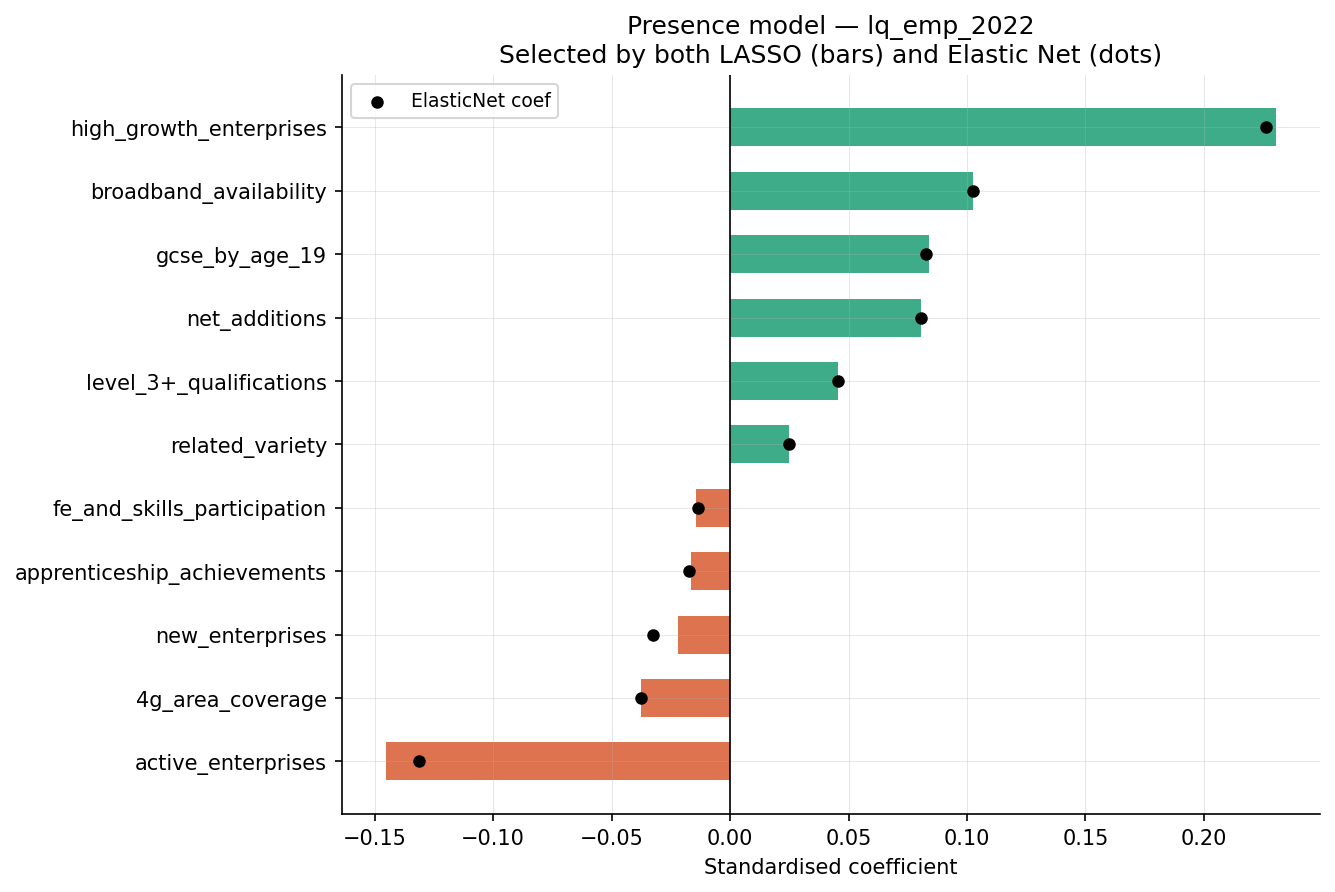

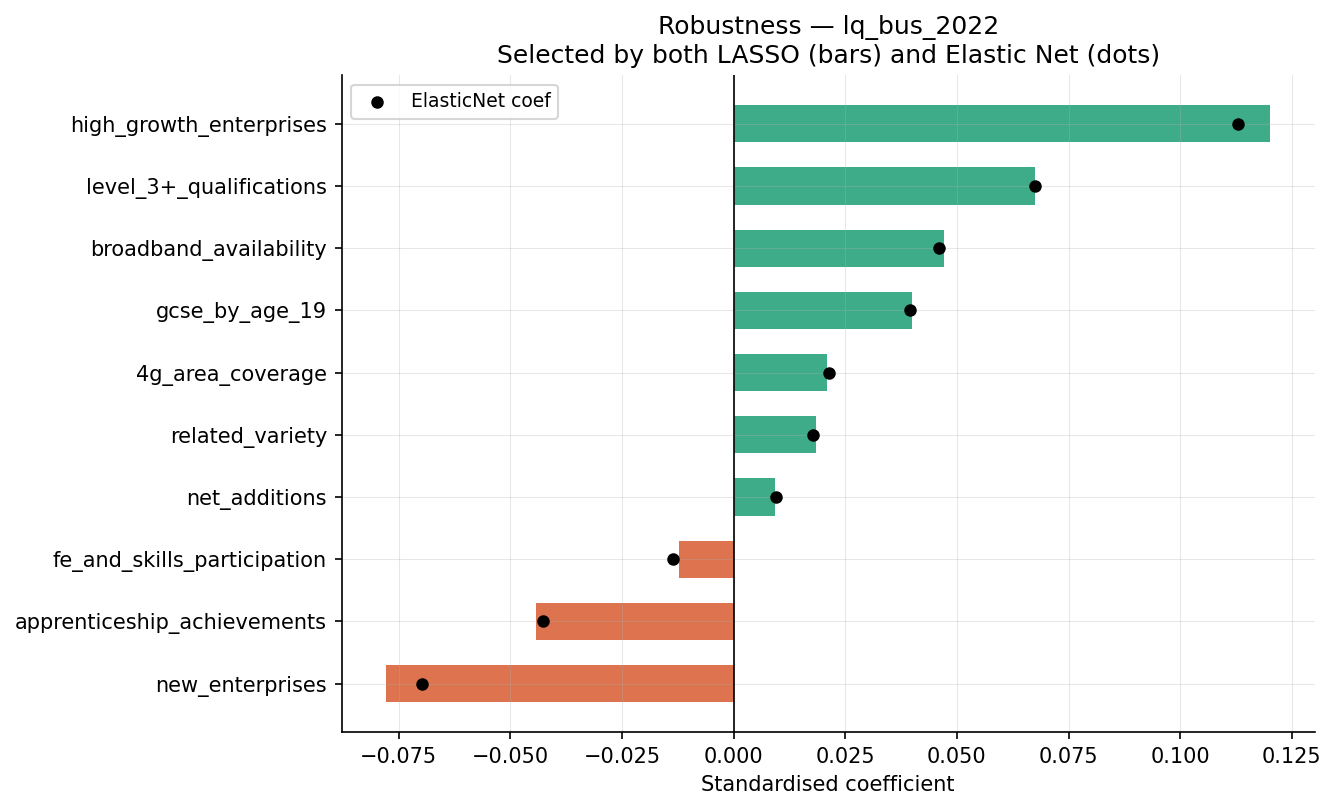

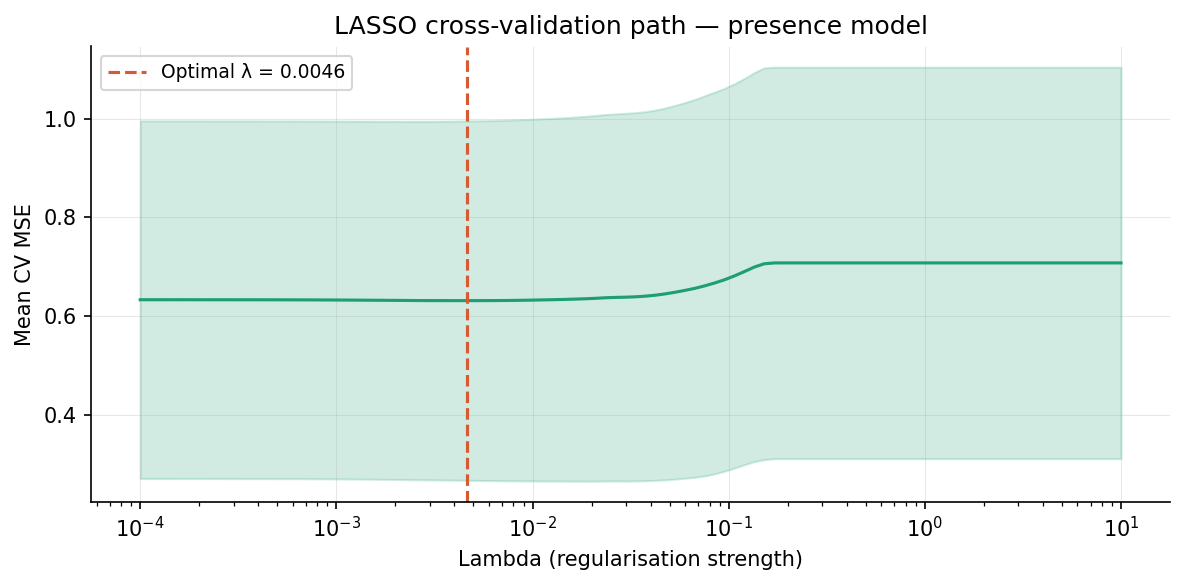

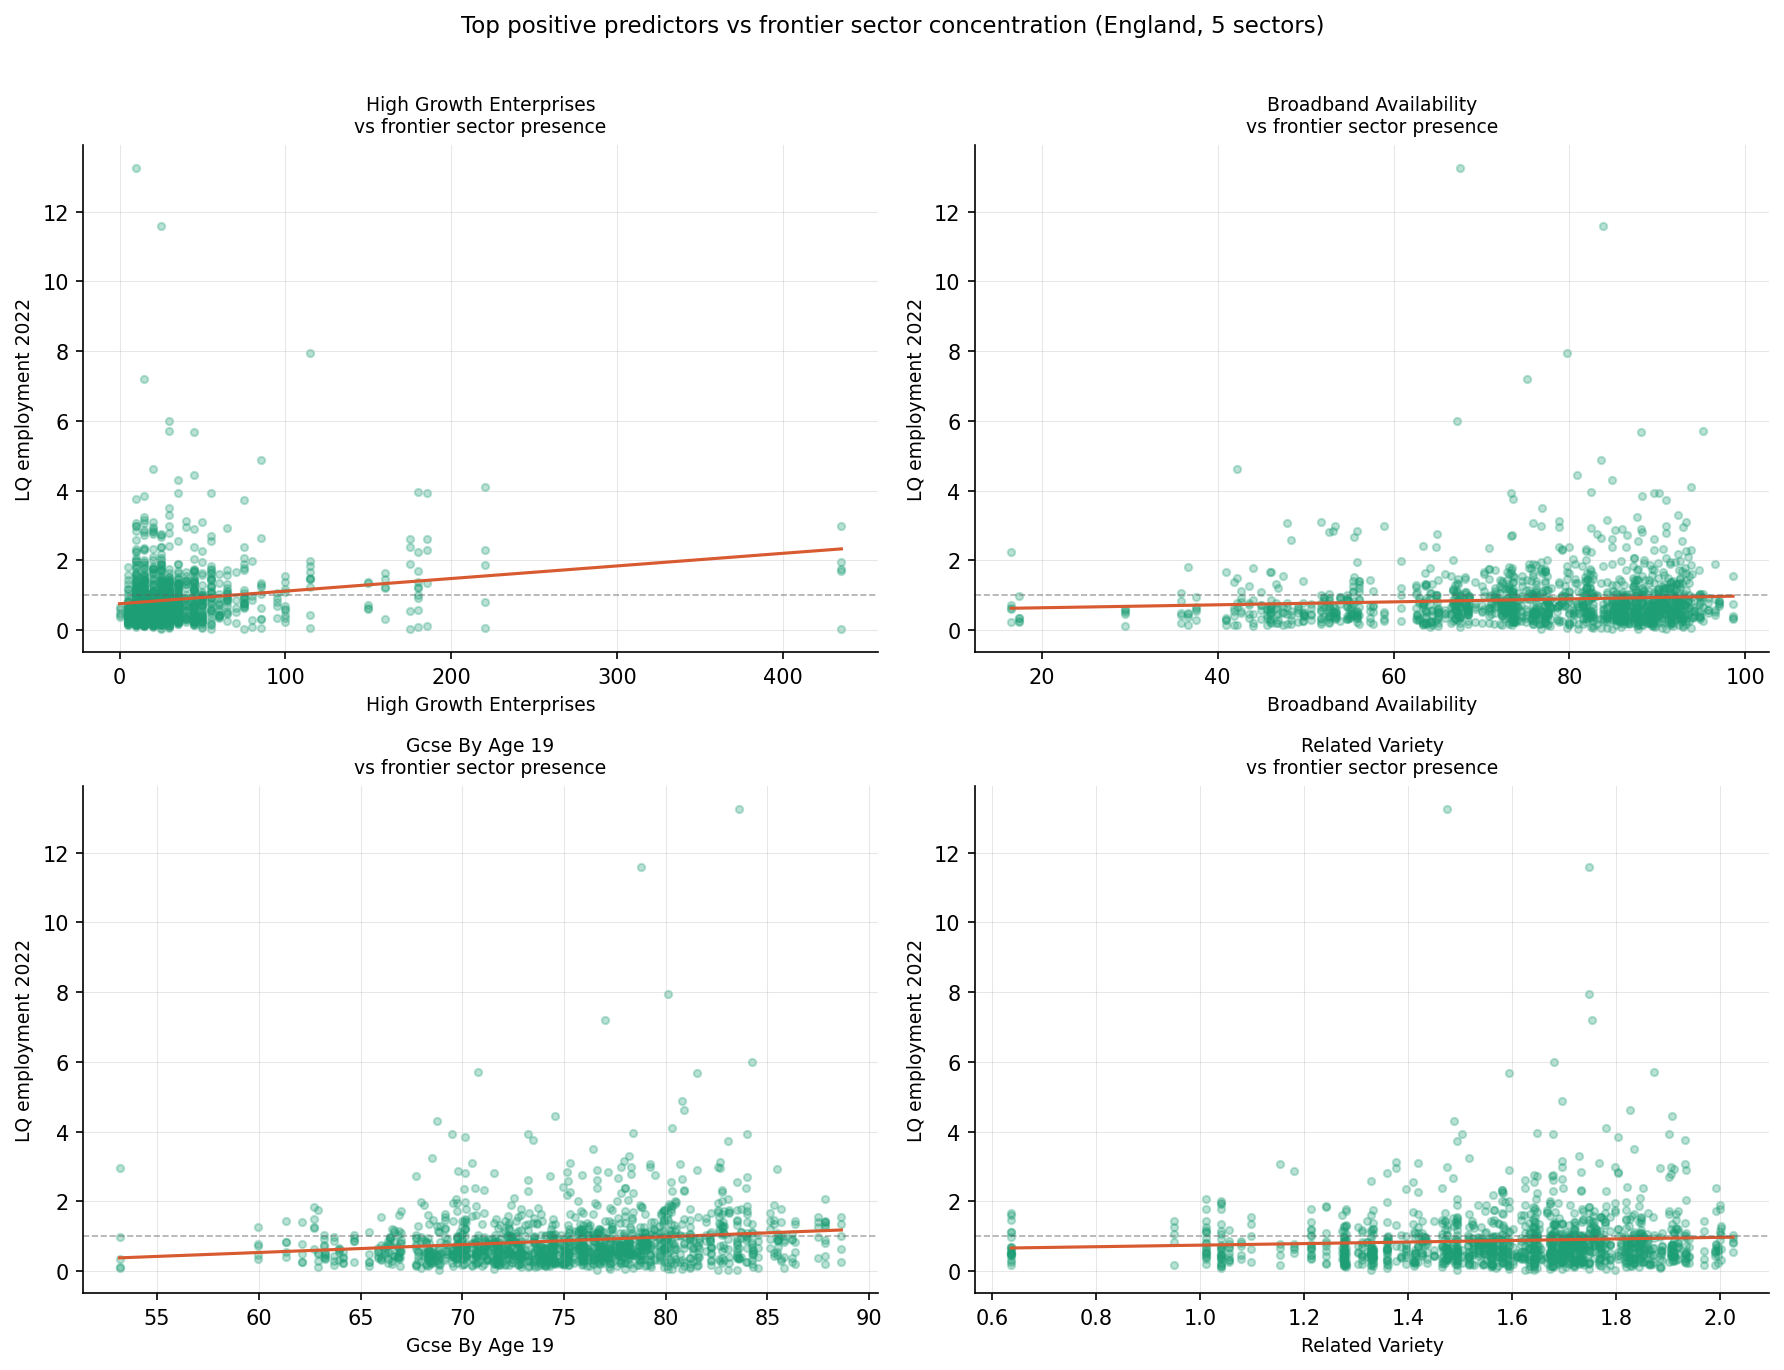

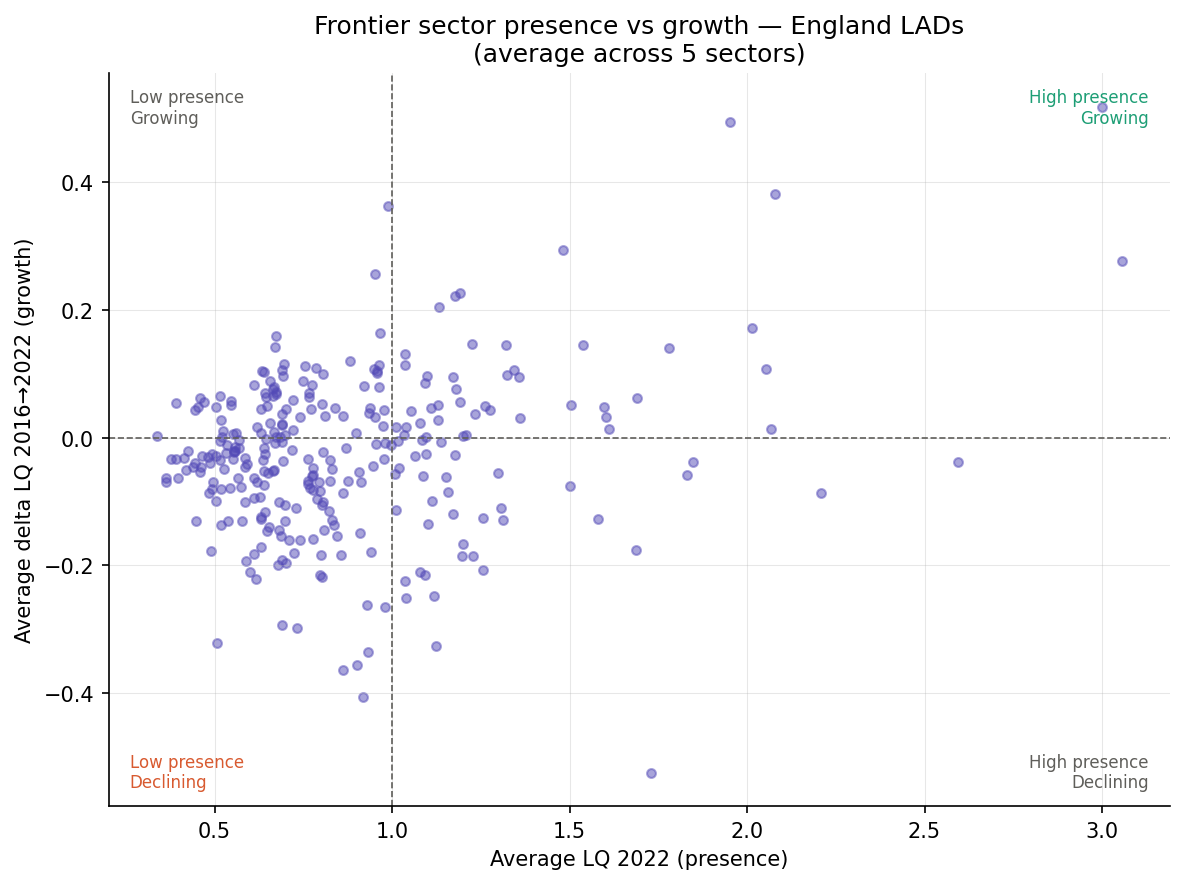

In [12]:
# ============================================================
# 6. RESULTS VISUALISATION
# ============================================================

print("\n" + "="*60)
print("SECTION 6 — RESULTS VISUALISATION")
print("="*60)

# ── 6.1 Coefficient plot — presence model ───────────────────
def plot_coefficients(results, label, filename, lasso_col="lasso_coef"):
    if results is None:
        return
    sel = (results[results["selected_both"] & ~results["is_sector"]]
           .sort_values(lasso_col))
    if len(sel) == 0:
        print(f"  No variables selected for {label}")
        return

    colors = [CORAL if c < 0 else TEAL for c in sel[lasso_col]]
    fig, ax = plt.subplots(figsize=(9, max(3, len(sel) * 0.55)))
    bars = ax.barh(sel["variable"], sel[lasso_col],
                   color=colors, height=0.6, alpha=0.85)

    # Also plot ElasticNet as dots for comparison
    ax.scatter(sel["enet_coef"], sel["variable"],
               color="black", zorder=5, s=25, label="ElasticNet coef")

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Standardised coefficient")
    ax.set_title(f"{label}\nSelected by both LASSO (bars) and Elastic Net (dots)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_coefficients(r_presence, "Presence model — lq_emp_2022",
                  "04_coefs_presence.png")
plot_coefficients(r_bus, "Robustness — lq_bus_2022",
                  "05_coefs_bus.png")

# ── 6.2 Lambda path — cross-validation ──────────────────────
if r_presence is not None:
    # Refit to get CV path (need raw lasso object)
    model_df = cs_final[feature_cols + ["lq_emp_2022"]].dropna()
    X_scaled = StandardScaler().fit_transform(model_df[feature_cols].values)
    y_pres   = model_df["lq_emp_2022"].values
    cv       = KFold(n_splits=10, shuffle=True, random_state=42)
    lasso_path = LassoCV(alphas=np.logspace(-4, 1, 100), cv=cv,
                         max_iter=10000, random_state=42)
    lasso_path.fit(X_scaled, y_pres)

    fig, ax = plt.subplots(figsize=(8, 4))
    mse_mean = np.mean(lasso_path.mse_path_, axis=1)
    mse_std  = np.std(lasso_path.mse_path_,  axis=1)
    ax.semilogx(lasso_path.alphas_, mse_mean, color=TEAL, linewidth=1.5)
    ax.fill_between(lasso_path.alphas_,
                    mse_mean - mse_std, mse_mean + mse_std,
                    alpha=0.2, color=TEAL)
    ax.axvline(lasso_path.alpha_, color=CORAL, linewidth=1.5,
               linestyle="--", label=f"Optimal λ = {lasso_path.alpha_:.4f}")
    ax.set_xlabel("Lambda (regularisation strength)")
    ax.set_ylabel("Mean CV MSE")
    ax.set_title("LASSO cross-validation path — presence model")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_lasso_cv_path.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── 6.3 Scatter — top predictors vs LQ ──────────────────────
top_vars = ["high_growth_enterprises", "broadband_availability",
            "gcse_by_age_19", "related_variety"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    plot_data = cs_final[[var, "lq_emp_2022", "is8_sector_Advanced Manufacturing"]].dropna()
    axes[i].scatter(plot_data[var], plot_data["lq_emp_2022"],
                    alpha=0.3, s=12, color=TEAL)
    # Add trend line
    z = np.polyfit(plot_data[var], plot_data["lq_emp_2022"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_data[var].min(), plot_data[var].max(), 100)
    axes[i].plot(x_line, p(x_line), color=CORAL, linewidth=1.5)
    axes[i].axhline(1, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.5)
    axes[i].set_xlabel(var.replace("_", " ").title(), fontsize=9)
    axes[i].set_ylabel("LQ employment 2022", fontsize=9)
    axes[i].set_title(f"{var.replace('_', ' ').title()}\nvs frontier sector presence", fontsize=9)

plt.suptitle("Top positive predictors vs frontier sector concentration (England, 5 sectors)",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_scatter_top_predictors.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 6.4 Presence vs growth scatter ──────────────────────────
lad_lq = (cs_final.groupby("geography_code")
          .agg(lq_emp_2022=("lq_emp_2022", "mean"),
               delta_lq_emp=("delta_lq_emp", "mean"),
               geography_name=("geography_name", "first"))
          .reset_index())

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(lad_lq["lq_emp_2022"], lad_lq["delta_lq_emp"],
           alpha=0.5, s=18, color=PURPLE)
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.axvline(1, color=GRAY, linewidth=0.8, linestyle="--")

# Quadrant labels
ax.text(0.02, 0.98, "Low presence\nGrowing", transform=ax.transAxes,
        va="top", fontsize=8, color=GRAY)
ax.text(0.98, 0.98, "High presence\nGrowing", transform=ax.transAxes,
        va="top", ha="right", fontsize=8, color=TEAL)
ax.text(0.02, 0.02, "Low presence\nDeclining", transform=ax.transAxes,
        va="bottom", fontsize=8, color=CORAL)
ax.text(0.98, 0.02, "High presence\nDeclining", transform=ax.transAxes,
        va="bottom", ha="right", fontsize=8, color=GRAY)

ax.set_xlabel("Average LQ 2022 (presence)")
ax.set_ylabel("Average delta LQ 2016→2022 (growth)")
ax.set_title("Frontier sector presence vs growth — England LADs\n(average across 5 sectors)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_presence_vs_growth.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ============================================================
# 7. POST-SELECTION OLS WITH CLUSTERED STANDARD ERRORS
# ============================================================

print("\n" + "="*60)
print("SECTION 7 — POST-SELECTION OLS")
print("="*60)
# LASSO selects variables — OLS gives proper standard errors
# Cluster at LAD level: 5 rows per LAD are not independent

# ── Fix ALL problematic column names at once ─────────────────
col_rename = {
    "level_3+_qualifications":  "level3plus_qualifications",
    "4g_area_coverage":         "coverage_4g",
}
# Also fix sector dummy spaces
for c in sector_dummies:
    col_rename[c] = c.replace(" ", "_")

# Apply to dataframe
cs_final = cs_final.rename(columns=col_rename)

# Update the selected variables list to match new names
def clean_varname(v):
    return col_rename.get(v, v.replace(" ", "_"))

selected_vars_clean  = [clean_varname(v) for v in sorted(s_presence)]
sector_dummies_clean = [clean_varname(v) for v in sector_dummies]

# ── Re-run OLS ───────────────────────────────────────────────
formula_vars = selected_vars_clean + sector_dummies_clean
formula = "lq_emp_2022 ~ " + " + ".join(formula_vars)
print("Formula:")
print(formula)

ols_df = cs_final[
    ["geography_code", "lq_emp_2022"] +
    selected_vars_clean + sector_dummies_clean
].dropna()

ols_model = smf.ols(formula, data=ols_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": ols_df["geography_code"]}
)

print(f"\nPost-LASSO OLS — presence model")
print(f"N = {int(ols_model.nobs):,} | R² = {ols_model.rsquared:.3f}")
print(ols_model.summary2().tables[1].round(4))
ols_model.summary2().tables[1].to_csv(OUTPUT_DIR / "ols_results_presence.csv")


SECTION 7 — POST-SELECTION OLS
Formula:
lq_emp_2022 ~ coverage_4g + active_enterprises + apprenticeship_achievements + broadband_availability + fe_and_skills_participation + gcse_by_age_19 + high_growth_enterprises + level3plus_qualifications + net_additions + new_enterprises + related_variety + is8_sector_Advanced_Manufacturing + is8_sector_Creative_Industries + is8_sector_Digital_and_Technologies + is8_sector_Financial_Services

Post-LASSO OLS — presence model
N = 1,450 | R² = 0.137
                                      Coef.  Std.Err.       z   P>|z|  [0.025  \
Intercept                            2.1754    3.2420  0.6710  0.5022 -4.1788   
coverage_4g                         -0.0354    0.0340 -1.0414  0.2977 -0.1019   
active_enterprises                  -0.0000    0.0000 -2.1444  0.0320 -0.0001   
apprenticeship_achievements         -0.0002    0.0002 -1.1066  0.2685 -0.0005   
broadband_availability               0.0074    0.0018  4.2357  0.0000  0.0040   
fe_and_skills_participa


SECTION 8 — ROBUSTNESS CHECKS

Winsorised 6-sector sample: 1,740 rows
  delta_lq winsorised to [-1.419, 1.492]

>>> ROBUSTNESS A: Presence — 6 sectors winsorised

  6 sectors winsorised, LQ presence
  N=1,740 | lambda=0.00206 | l1_ratio=0.10
  LAD indicators selected by BOTH: 11
                   variable  lasso_coef  enet_coef
    high_growth_enterprises    0.235472   0.214651
         active_enterprises   -0.128097  -0.089734
     broadband_availability    0.111836   0.109707
             gcse_by_age_19    0.077054   0.073806
            new_enterprises   -0.072473  -0.072527
fe_and_skills_participation   -0.059364  -0.057319
              net_additions    0.042086   0.042467
    level_3+_qualifications    0.036548   0.038355
           4g_area_coverage   -0.033771  -0.032327
            related_variety    0.033246   0.032140
apprenticeship_achievements   -0.016835  -0.017442
  Dropped by both: ['apprenticeship_starts']

Life Sciences standalone: 290 rows

>>> ROBUSTNESS B: Life Sc

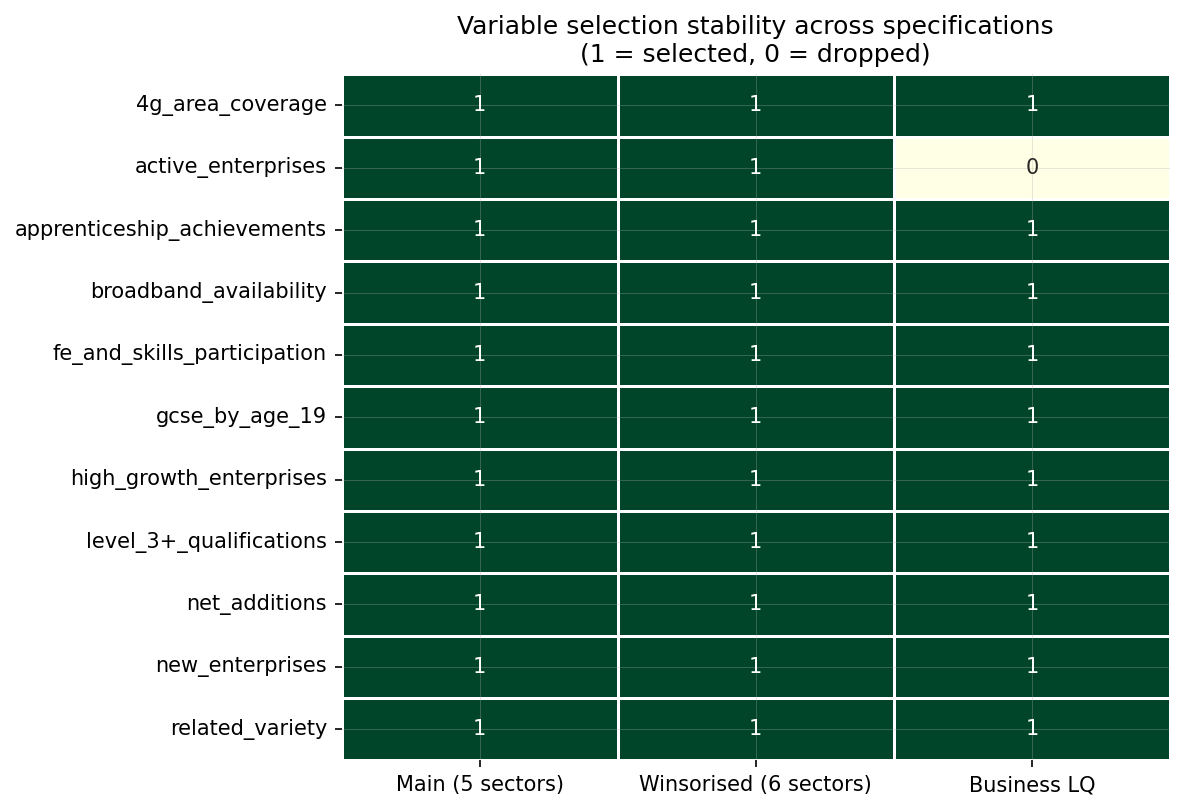

In [14]:
# ============================================================
# 8. ROBUSTNESS CHECKS
# ============================================================

print("\n" + "="*60)
print("SECTION 8 — ROBUSTNESS CHECKS")
print("="*60)

# ── 8.1 Winsorised 6-sector model (includes Life Sciences) ──
cs_6 = cs[~cs["is8_sector"].isin(["Defence"])].copy()
cs_6 = cs_6[cs_6["geography_code"].astype(str).str.startswith("E")].copy()
cs_6 = cs_6[cs_6[LAD_INDICATORS].notna().all(axis=1)].copy()
p01  = cs_6["delta_lq_emp"].quantile(0.01)
p99  = cs_6["delta_lq_emp"].quantile(0.99)
cs_6["delta_lq_emp"] = cs_6["delta_lq_emp"].clip(p01, p99)
cs_6["lq_emp_2022"]  = cs_6["lq_emp_2022"].clip(
    cs_6["lq_emp_2022"].quantile(0.01),
    cs_6["lq_emp_2022"].quantile(0.99))
cs_6, sec6 = add_sector_dummies(cs_6)
feat6 = LAD_INDICATORS + sec6

print(f"\nWinsorised 6-sector sample: {len(cs_6):,} rows")
print(f"  delta_lq winsorised to [{p01:.3f}, {p99:.3f}]")

print("\n>>> ROBUSTNESS A: Presence — 6 sectors winsorised")
r_win = run_lasso(cs_6, "lq_emp_2022", feat6,
                  "6 sectors winsorised, LQ presence")

# ── 8.2 Life Sciences standalone ────────────────────────────
cs_ls = cs[cs["is8_sector"] == "Life Sciences"].copy()
cs_ls = cs_ls[cs_ls["geography_code"].astype(str).str.startswith("E")].copy()
cs_ls = cs_ls[cs_ls[LAD_INDICATORS].notna().all(axis=1)].copy()

print(f"\nLife Sciences standalone: {len(cs_ls):,} rows")
print("\n>>> ROBUSTNESS B: Life Sciences standalone")
r_ls = run_lasso(cs_ls, "lq_emp_2022", LAD_INDICATORS,
                 "Life Sciences only, presence", lad_vars=LAD_INDICATORS)

# ── 8.3 Stability comparison ─────────────────────────────────
s_win = selected_lad(r_win)
s_ls  = selected_lad(r_ls)

print("\n" + "="*55)
print("ROBUSTNESS STABILITY SUMMARY")
print(f"  Main presence (5 sectors):          {sorted(s_presence)}")
print(f"  Winsorised 6-sector:                {sorted(s_win)}")
print(f"  Stable across both specs:           {sorted(s_presence & s_win)}")
print(f"  Life Sciences standalone selected:  {sorted(s_ls)}")

# ── 8.4 Stability plot ───────────────────────────────────────
all_vars = sorted(s_presence | s_win)
if len(all_vars) > 0:
    stability_df = pd.DataFrame({
        "variable": all_vars,
        "Main (5 sectors)":      [1 if v in s_presence else 0 for v in all_vars],
        "Winsorised (6 sectors)":[1 if v in s_win else 0 for v in all_vars],
        "Business LQ":           [1 if v in s_bus else 0 for v in all_vars],
    }).set_index("variable")

    fig, ax = plt.subplots(figsize=(8, max(4, len(all_vars) * 0.5)))
    sns.heatmap(stability_df, annot=True, fmt="d", cmap="YlGn",
                linewidths=0.5, cbar=False,
                annot_kws={"size": 10}, ax=ax)
    ax.set_title("Variable selection stability across specifications\n(1 = selected, 0 = dropped)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "09_stability_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Sample:    {len(cs_final):,} rows | "
      f"{cs_final['geography_code'].nunique()} English LADs | 5 sectors")
print(f"  Growth model:   {len(s_growth)} variables selected (lambda hit ceiling)")
print(f"  Presence model: {len(s_presence)} variables selected")
print(f"  Robust to business LQ: {sorted(s_presence & s_bus)}")
print(f"\n  Output files saved to: {OUTPUT_DIR.resolve()}")
print("\nFiles produced:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"    {f.name}")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"    {f.name}")


FINAL SUMMARY
  Sample:    1,450 rows | 290 English LADs | 5 sectors
  Growth model:   0 variables selected (lambda hit ceiling)
  Presence model: 11 variables selected
  Robust to business LQ: ['4g_area_coverage', 'apprenticeship_achievements', 'broadband_availability', 'fe_and_skills_participation', 'gcse_by_age_19', 'high_growth_enterprises', 'level_3+_qualifications', 'net_additions', 'new_enterprises', 'related_variety']

  Output files saved to: G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\notebooks\Diane\output

Files produced:
    01_outcome_distributions.png
    02_lq_by_sector.png
    03_indicator_correlations.png
    04_coefs_presence.png
    05_coefs_bus.png
    06_lasso_cv_path.png
    07_scatter_top_predictors.png
    08_presence_vs_growth.png
    09_stability_heatmap.png
    ols_results_presence.csv
    summary_statistics.csv
